In [2]:
import matplotlib.pyplot as plt
import numpy as np
import copy
import os
from pathlib import Path
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, random_split

import_path = Path.cwd().parent
os.sys.path.insert(0, str(import_path))
import feature_utils as futils
import utils
from configs import get_specgram_config
from plot_functions import plot_features
import autoencoder_functions as aefuncs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# feat_path = Path(r"D:\clustering\clustering_outputs_4121\downsampled_features")
feat_path = Path(r"D:\second_extraction")
files = sorted(feat_path.rglob("*.npz"))

for path in files[0:2]:
    with np.load(path, allow_pickle=False) as z:
        print("Arrays in file:", z.files)
        for k in z.files:
            a = z[k]
            print(f" sample: {a.ravel()[:5]} with shape {a.shape}")

Arrays in file: ['feature', 'sr', 'source_path']
 sample: [-100. -100. -100. -100. -100.] with shape (1, 128, 33125)
 sample: [64000] with shape ()
 sample: ['/home/trh104/original_data/Aug_6229/6229.220802122000.wav'] with shape ()
Arrays in file: ['feature', 'sr', 'source_path']
 sample: [-100. -100. -100. -100. -100.] with shape (1, 128, 33125)
 sample: [64000] with shape ()
 sample: ['/home/trh104/original_data/Aug_6229/6229.220802124000.wav'] with shape ()


In [4]:
# feat_path2 = Path(r"D:\clustering\clustering_outputs_6064\downsampled_features")
# files2 = sorted(feat_path2.glob("*.npz"))
# for path in files[0:2]:
#     with np.load(path, allow_pickle=False) as z:
#         print("Arrays in file:", z.files)
#         for k in z.files:
#             a = z[k]
#             print(f" sample: {a.ravel()[:5]} with shape {a.shape}")

In [5]:
# Load pca stats.
# pca_stats_path = Path(r"D:\clustering\clustering_outputs_4121\pca_kmeans_batches.npz")
pca_stats_path = Path(r"D:\segs_clust_5762\segments_ipca.npz")
with np.load(pca_stats_path, allow_pickle=False) as z:
    print("Arrays in file:", z.files)
    print("Scaler mean =", z["scaler_mean"], "with shape", z["scaler_mean"].shape)
    print("Scaler scale =", z["scaler_scale"], "with shape", z["scaler_scale"].shape)
    for k in z.files:
        a = z[k]
        print(f" sample: {a.ravel()[:2]} with shape {a.shape}")

Arrays in file: ['ipca_components', 'ipca_mean', 'scaler_mean', 'scaler_scale', 'explained_variance', 'explained_variance_ratio', 'n_components']
Scaler mean = [-35.450012 -35.447582 -35.441814 ... -38.98506  -38.983627 -38.9765  ] with shape (15300,)
Scaler scale = [11.148563 11.148473 11.15281  ... 13.083109 13.082709 13.081128] with shape (15300,)
 sample: [0.00729395 0.00729705] with shape (8192, 15300)
 sample: [ 2.4588156e-08 -1.6535087e-07] with shape (15300,)
 sample: [-35.450012 -35.447582] with shape (15300,)
 sample: [11.148563 11.148473] with shape (15300,)
 sample: [13929.217     185.58609] with shape (8192,)
 sample: [0.9104049  0.01212979] with shape (8192,)
 sample: [8192] with shape ()


In [ ]:
mels_start, mels_end = 9, 60
n_mels, key = 128, "feature"
# Gives a matrix stack with shape (n files * t, n_mels), ex. for 2 files = (66250, 128).
subsample_files = files[0:2] 
x, ids = futils.load_features_TxB(subsample_files, n_mels=n_mels, key=key)
print("x shape =", x.shape)

x shape = (66250, 128)


#### Validation sample

In [7]:
val1_path = r"D:\second_extraction\Tracy_6230\6230.220917120000.npz"
val2_path = r"D:\second_extraction\Tracy_6230\6230.221003000000.npz"
s1 = np.load(val1_path)["feature"]
spec = s1[0]

sr = 64000
hop_length = 512
fps = sr / hop_length
t_start, t_end = 25.0, 30.0
i_start = int(t_start * fps)
i_end = int(t_end * fps)

seg1 = spec[mels_start:mels_end, i_start:i_end]

# Auto-encoder
- Should the input be normalized first?
- Is the input batches of flattened spectrograms (t, M) or the full matrix (T, M)?

In [ ]:
# Prepare data set.
mels_start, mels_end = 9, 60
key = "feature"
segment_sec, clip_sec = 5.0, 265.0
T_target = 300
all_paths = sorted(feat_path.rglob("*.npz"))
batch_size = 512

with np.load(all_paths[0], mmap_mode="r") as z:
    arr0 = np.squeeze(z[key]) # (1, 128, t) or (128, t).
    if arr0.ndim == 3:
        arr0 = arr0[0]
    t_total = arr0.shape[-1]

frames_per_sec = t_total / clip_sec
segment_frames = int(round(frames_per_sec * segment_sec))

n_files = 200
rng = np.random.default_rng(104)
n_files = min(n_files, len(all_paths))
sampled_paths = rng.choice(all_paths, size=n_files, replace=False)
full_dataset = aefuncs.SegmentLogMelDataset(sampled_paths, key=key, mels_start=mels_start, mels_end=mels_end
                                   , segment_frames=segment_frames, max_frames=None, T_target=T_target)

# Include validation narwhal call in validation set.
val1_name = Path(val1_path).name
val_indices = []
train_candidate_indices = []
for idx in range(len(full_dataset)):
    path, start, end = full_dataset.index[idx]
    if Path(path).name == val1_name:
        val_indices.append(idx)
    else:
        train_candidate_indices.append(idx)
n_extra_val = max(0, int(0.2 * len(full_dataset)) - len(val_indices))
extra_val_indices = list(np.random.default_rng(104).choice(train_candidate_indices, size=n_extra_val, replace=False))
val_indices = val_indices + extra_val_indices
train_indices = [i for i in train_candidate_indices if i not in extra_val_indices]

# Trainining/validation split.
n = len(full_dataset)
n_val = max(1, int(0.2 * n))
n_train = n - n_val
train_set = Subset(full_dataset, train_indices)
val_set = Subset(full_dataset, val_indices)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

In [13]:
# Check a data point from the dataloader.
data_point, meta = next(iter(train_loader))

torch.Size([512, 15300])
Total segments in full_dataset: 10597
Training segments = 8478
Validation segments = 2119


In [15]:
print(data_point.shape)
print("Example data:", data_point[0, 0:10], "max value:", max(data_point[0, :]))
print("Max and min values in batch:", torch.max(data_point), torch.min(data_point))

print("Total segments in full_dataset:", len(full_dataset))
print("Training segments =", len(train_set))
print("Validation segments =", len(val_set))

torch.Size([512, 15300])
Example data: tensor([-32.4582, -37.1533, -36.0631, -31.5385, -34.8181, -40.5740, -37.7574,
        -33.6913, -34.2010, -39.7465]) max value: tensor(-0.1329)
Max and min values in batch: tensor(9.2661) tensor(-100.)
Total segments in full_dataset: 10597
Training segments = 8478
Validation segments = 2119


In [ ]:
# Dimensions.
x0, _ = next(iter(train_loader))
input_dim = x0.shape[1] # (t * M)
expo = 10
latent_dim = 2048 # 2**expo
hidden_dim = 512 # 2**(expo+1)

# Model.
n_epochs = 5
patience = 1
min_delta = 10
model = aefuncs.AE(input_dim=input_dim, latent_dim=latent_dim, hidden_dim=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [13]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
epochs_no_improve = 0
# Epochs.
for epoch in range(n_epochs):
    # Training phase.
    model.train()
    running_train = 0.0
    for x, _ in train_loader:
        x = x.to(device)
        # Optimization step.
        optimizer.zero_grad()
        x_hat, z = model(x)
        # Reconstruction loss.
        loss = F.mse_loss(x_hat, x)
        loss.backward()
        optimizer.step()

        running_train += loss.item() * x.size(0)
    train_loss = running_train / len(train_loader.dataset)
    
    # Validation phase.
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_hat, z = model(x)
            loss = F.mse_loss(x_hat, x)
            running_val += loss.item() * x.size(0)
    val_loss = running_val / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping.
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            break 
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model with val_loss =", best_val_loss)

Epoch [1/20], Train Loss: 989.8815, Val Loss: 163.1290
Epoch [2/20], Train Loss: 67.9381, Val Loss: 28.6808
Epoch [3/20], Train Loss: 21.3041, Val Loss: 17.0450
Epoch [4/20], Train Loss: 15.7525, Val Loss: 15.1829
Loaded best model with val_loss = 17.044970477068865


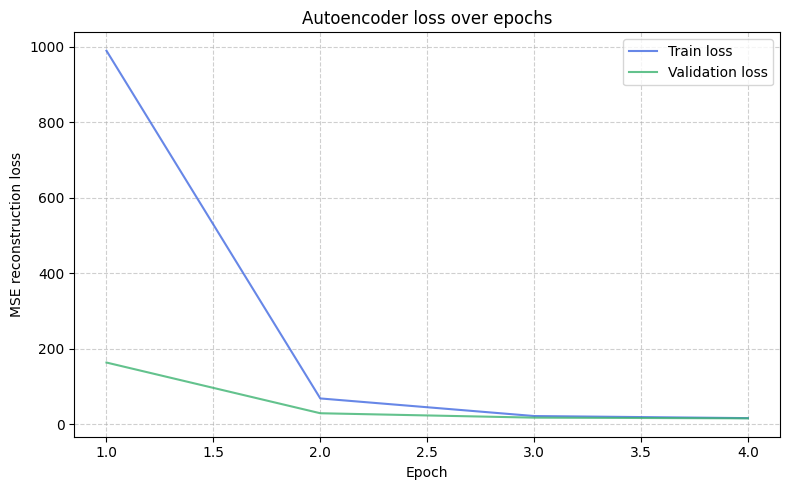

In [ ]:
# Actual number of epochs trained.
epochs = np.arange(1, 5)
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(epochs, train_losses, label="Train loss", color="royalblue", alpha=0.8)
ax.plot(epochs, val_losses, label="Validation loss", color="mediumseagreen", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE reconstruction loss")
plt.title("Autoencoder loss over epochs")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xticks(epochs)
plt.tight_layout()
plt.show()

## Reconstruction

In [ ]:
model.eval()
M_used = mels_end - mels_start
T_target = full_dataset.T_target
# 1) Downsample.
seg1_ds = futils.downsample_time_avgpool_from_db(seg1,T_target=T_target, ref=1.0,).numpy() # shape = (M_used, T_target).
# 2) Flatten and make a batch of size 1.
x_val = torch.from_numpy(seg1_ds).flatten().unsqueeze(0).to(device)  # (1, D).
# 3) Encode and reconstruct.
with torch.no_grad():
    x_hat, z = model(x_val) # x_hat: (1, D), z: (1, latent_dim).
# 4) Reshape reconstruction back to (M_used, T_target).
x_hat_np = x_hat.squeeze(0).cpu().numpy().reshape(M_used, T_target)
z_np = z.squeeze(0).cpu().numpy()

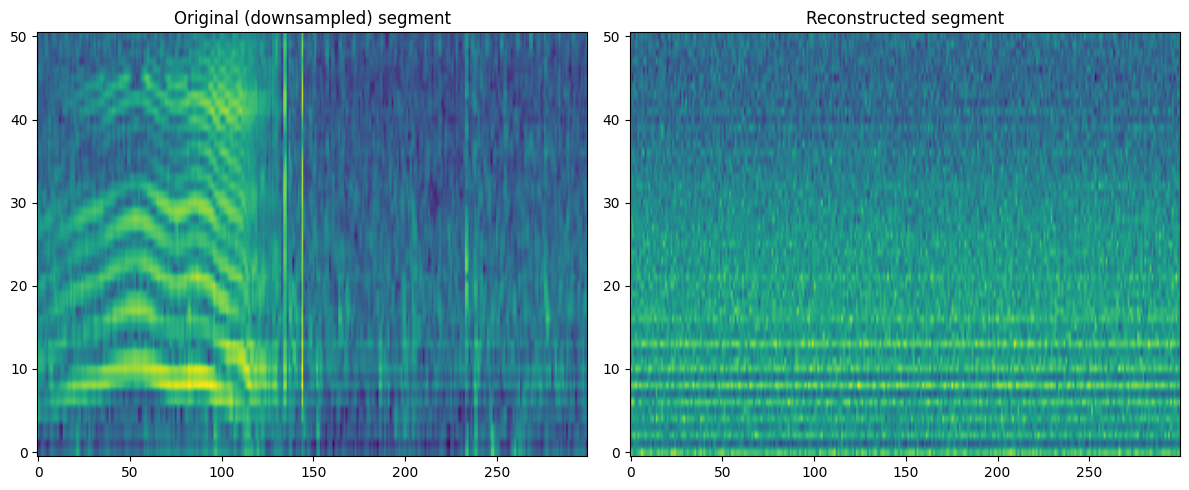

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.imshow(seg1_ds, aspect="auto", origin="lower")
plt.title("Original downsampled segment")

plt.subplot(1,2,2)
plt.imshow(x_hat_np, aspect="auto", origin="lower")
plt.title("Reconstructed segment")

plt.tight_layout()
plt.show()

## Clustering

In [ ]:
model.eval()

all_z = []
all_paths = []

with torch.no_grad():
    for x, meta in train_loader:
        x = x.to(device)
        _, z = model(x)
        all_z.append(z.cpu())
        all_paths.extend(meta)
Z = torch.cat(all_z, dim=0).numpy()
print("Z shape =", Z.shape)

k = 8
kmeans = MiniBatchKMeans(n_clusters=k, random_state=104, batch_size=256)
kmeans.fit(Z)
labels = kmeans.labels_
centers = kmeans.cluster_centers_
inertia = kmeans.inertia_

In [ ]:
pca = PCA(n_components=2, random_state=104)
Z2 = pca.fit_transform(Z)
centers2 = pca.transform(centers)

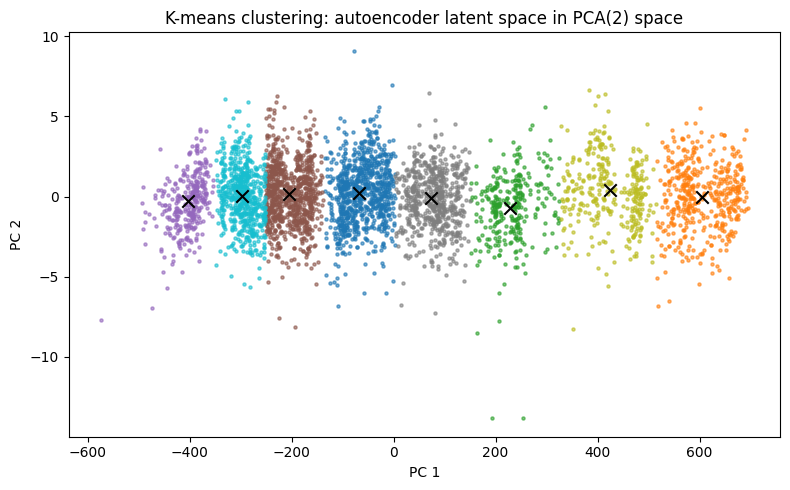

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, k))
for j in range(k):
    idx = (labels == j)
    ax.scatter(Z2[idx, 0], Z2[idx, 1], color=colors[j], s=5, label=f"Cluster {j}", alpha=0.6)
ax.scatter(centers2[:, 0], centers2[:, 1], c='black', s=80, marker='x', label='Centroids')
ax.set_title("K-means clustering: autoencoder latent embeddings in PCA(2) space")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
plt.tight_layout()
plt.show()